# Astrometry: residual (head) vs raw offset spread

Per-source spread for all 790 ECDFS tiles with the latest (vispeak) latent position head.
x = raw classical band$-$VIS offset, y = offset after the head correction; all 10 bands pooled,
50-mas-deduped anchors. Points below the y=x line are improved by the head. (Label-based, i.e.
residual is offset to the VIS-centroid convention.)

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError
REPO=find_repo_root()
CACHE=REPO/'models/checkpoints/latent_position_v10_vispeak/anchors_centernet_v10_vispeak_dedup.npz'
OUT=REPO/'io/_nb09_outputs/astrom_raw_vs_resid.png'
d=np.load(CACHE, allow_pickle=True)
BANDS=['u','g','r','i','z','y','nisp_Y','nisp_J','nisp_H']
raw=[]; res=[]; snr=[]
for b in BANDS:
    rr=np.asarray(d[f'{b}_raw'])*1000; hr=np.asarray(d[f'{b}_head_resid'])*1000
    raw.append(np.hypot(rr[:,0],rr[:,1])); res.append(np.hypot(hr[:,0],hr[:,1])); snr.append(np.asarray(d[f'{b}_snr']))
raw=np.concatenate(raw); res=np.concatenate(res); snr=np.concatenate(snr)
ok=(raw>0)&(res>0)&np.isfinite(raw)&np.isfinite(res)&np.isfinite(snr)&(snr>0); raw,res,snr=raw[ok],res[ok],snr[ok]
print(f'N anchors: {len(raw):,}')
print(f'raw median {np.median(raw):.1f} mas -> head-resid median {np.median(res):.1f} mas | improved (res<raw): {(res<raw).mean():.0%}')


N anchors: 199,487
raw median 54.2 mas -> head-resid median 13.0 mas | improved (res<raw): 92%


saved io/_nb09_outputs/astrom_raw_vs_resid.png


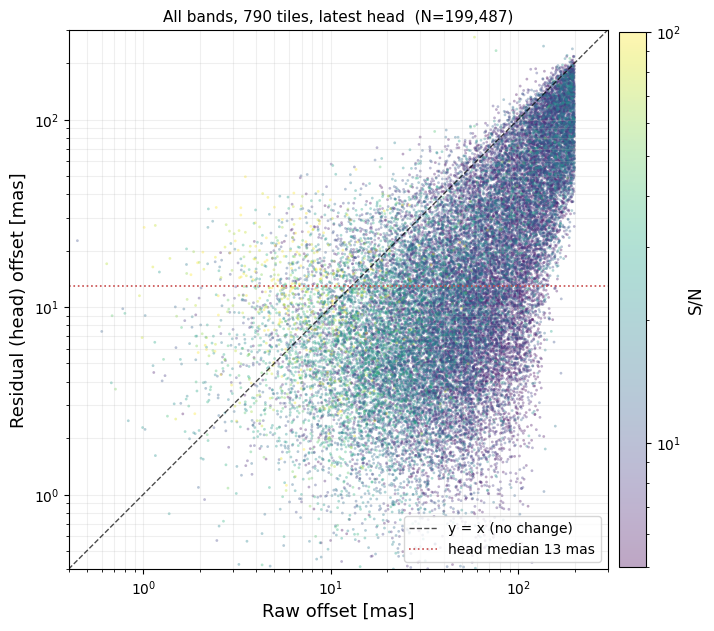

In [2]:
rng=np.random.default_rng(0)
idx=rng.choice(len(raw), min(30000,len(raw)), replace=False)
fig,ax=plt.subplots(figsize=(7.5,7))
from matplotlib.colors import LogNorm
o=np.argsort(snr[idx])   # bright on top
sc=ax.scatter(raw[idx][o],res[idx][o],c=snr[idx][o],s=4,alpha=0.35,edgecolors='none',cmap='viridis',norm=LogNorm(vmin=5,vmax=100),rasterized=True)
cb=fig.colorbar(sc,ax=ax,fraction=0.046,pad=0.02); cb.set_label('S/N',fontsize=12)
lim=[0.4,300]
ax.plot(lim,lim,'k--',lw=1,alpha=0.7,label='y = x (no change)')
ax.axhline(np.median(res),color='#c84b4b',ls=':',lw=1.2,label=f'head median {np.median(res):.0f} mas')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
ax.set_xlabel('Raw offset [mas]',fontsize=13); ax.set_ylabel('Residual (head) offset [mas]',fontsize=13)
ax.grid(True,which='both',alpha=0.2); ax.legend(fontsize=10,loc='lower right')
ax.set_title(f'All bands, 790 tiles, latest head  (N={len(raw):,})',fontsize=11)
OUT.parent.mkdir(parents=True,exist_ok=True)
fig.savefig(OUT,dpi=130,bbox_inches='tight'); print('saved',OUT.relative_to(REPO)); plt.show()


MER H/size not yet available -> 2 panels (S/N, VIS mag). Re-run after the IRSA pull lands.


saved io/_nb09_outputs/astrom_hexbin.png


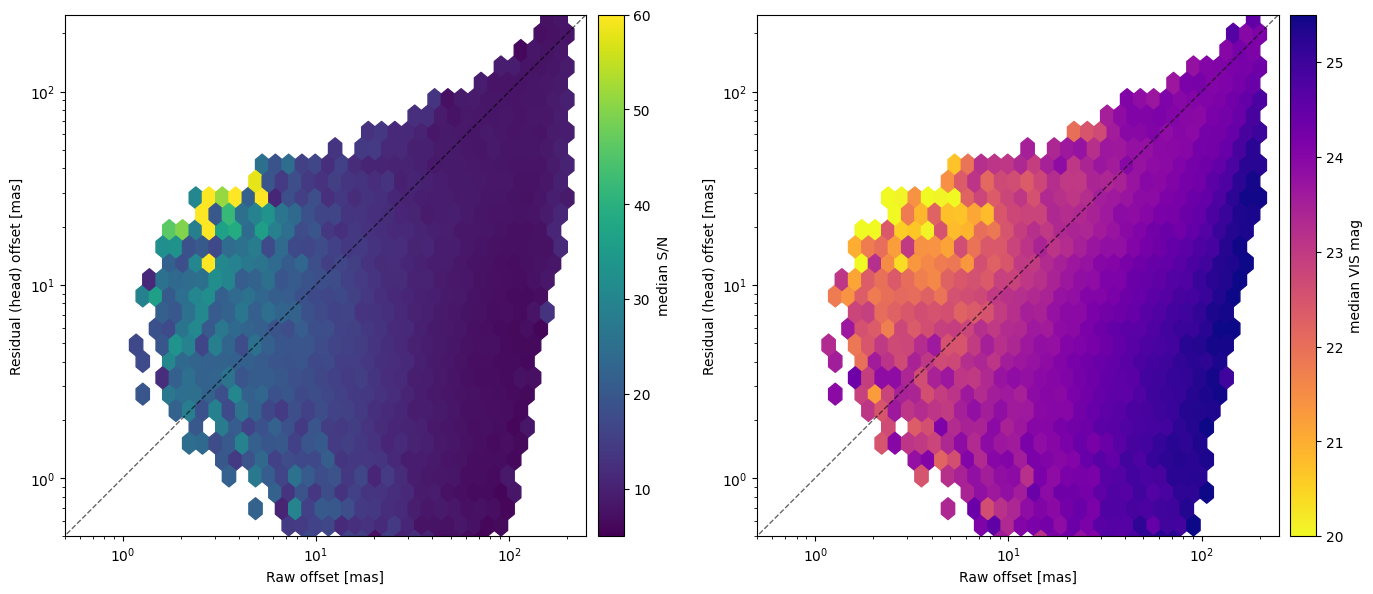

In [3]:
# ---- density hexbins colored by property (S/N, VIS mag; + H mag, size if MER pull available) ----
from astropy.io import fits
from scipy.spatial import cKDTree
# recompute ra/dec/snr aligned with raw/res (same pooling/filter as above)
BANDS=['u','g','r','i','z','y','nisp_Y','nisp_J','nisp_H']
RAW=[];RES=[];SNR=[];RA=[];DEC=[]
for b in BANDS:
    rr=np.asarray(d[f'{b}_raw'])*1000; hr=np.asarray(d[f'{b}_head_resid'])*1000
    RAW.append(np.hypot(*rr.T));RES.append(np.hypot(*hr.T));SNR.append(np.asarray(d[f'{b}_snr']))
    RA.append(np.asarray(d[f'{b}_ra']));DEC.append(np.asarray(d[f'{b}_dec']))
RAW=np.concatenate(RAW);RES=np.concatenate(RES);SNR=np.concatenate(SNR);RA=np.concatenate(RA);DEC=np.concatenate(DEC)
m0=(RAW>0)&(RES>0)&np.isfinite(RAW)&np.isfinite(RES)&(SNR>0)
RAW,RES,SNR,RA,DEC=RAW[m0],RES[m0],SNR[m0],RA[m0],DEC[m0]
cosd=np.cos(np.deg2rad(np.median(DEC)))

def match(cra,cdec,vals,rad=0.5):
    t=cKDTree(np.column_stack([cra*cosd,cdec])); dist,idx=t.query(np.column_stack([RA*cosd,DEC]),k=1)
    return np.where(dist*3600<rad, vals[idx], np.nan)

props=[(SNR,'median S/N','viridis',(5,60),False)]
# VIS mag from compact MER
mc=fits.open(REPO/'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_ECDFS_footprint.fits')[1].data
vmag=match(np.asarray(mc['ra'],float),np.asarray(mc['dec'],float),np.asarray(mc['mag_vis'],float))
props.append((vmag,'median VIS mag','plasma_r',(20,25.5),False))
# H mag + size from IRSA pull if available
hs=REPO/'data/edf_s_ood/catalogs_compact/mer_q1_ECDFS_Hsize.fits'
if hs.exists():
    h=fits.open(hs)[1].data
    hflux=np.asarray(h['flux_h_2fwhm_aper'],float)
    hmag_cat=np.where(hflux>0, 23.9-2.5*np.log10(hflux), np.nan)
    hmag=match(np.asarray(h['ra'],float),np.asarray(h['dec'],float),hmag_cat)
    size=match(np.asarray(h['ra'],float),np.asarray(h['dec'],float),np.asarray(h['semimajor_axis'],float)*0.1)  # arcsec
    props.append((hmag,'median H mag','plasma_r',(19,24.5),False))
    props.append((size,'median size (semimajor) [arcsec]','cividis',(0.1,0.6),False))
    print("MER H/size available -> 4 panels")
else:
    print("MER H/size not yet available -> 2 panels (S/N, VIS mag). Re-run after the IRSA pull lands.")

n=len(props); ncol=2; nrow=(n+1)//2
fig,axes=plt.subplots(nrow,ncol,figsize=(7*ncol,6*nrow)); axes=np.atleast_1d(axes).ravel()
for ax,(C,lab,cmap,vlim,_) in zip(axes,props):
    mm=np.isfinite(C)
    hb=ax.hexbin(RAW[mm],RES[mm],C=C[mm],reduce_C_function=np.median,gridsize=45,
                 xscale='log',yscale='log',cmap=cmap,mincnt=8,vmin=vlim[0],vmax=vlim[1])
    ax.plot([0.4,300],[0.4,300],'k--',lw=1,alpha=0.6)
    ax.set_xlim(0.5,250);ax.set_ylim(0.5,250);ax.set_aspect('equal')
    ax.set_xlabel('Raw offset [mas]');ax.set_ylabel('Residual (head) offset [mas]')
    fig.colorbar(hb,ax=ax,fraction=0.046,pad=0.02).set_label(lab)
for ax in axes[n:]: ax.axis('off')
plt.tight_layout()
HEXOUT=REPO/'io/_nb09_outputs/astrom_hexbin.png'
fig.savefig(HEXOUT,dpi=130,bbox_inches='tight'); print('saved',HEXOUT.relative_to(REPO)); plt.show()
